# COVID-19 Chest X-Ray Classification — Model Benchmark
Comparing four neural network architectures on the [COVID-19 Image Dataset (Kaggle)](https://www.kaggle.com/datasets/pranavraikokte/covid19-image-dataset):

| Model | Architecture | Why it's included |
|---|---|---|
| **1. Dense** | Flatten + Dense layers only | Baseline — no spatial awareness |
| **2. CNN** | Conv2D + MaxPooling layers | Exploits spatial structure in images |
| **3. Deep CNN (regularized)** | Deeper CNN + Dropout + BatchNorm | Tests whether more depth + regularization helps on a small dataset |
| **4. RNN** | Image rows treated as a sequence | Included for comparison — RNNs are built for *sequential* data (text, time series), not static images, so this is expected to underperform. It's included to demonstrate *why* architecture choice matters, not because it's a good fit. |

All four models are trained and evaluated identically, so their scores are directly comparable.

## 1. Setup and shared data pipeline

All four models will train on the exact same data pipeline, ensuring a fair comparison.

In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

train_dir = "/Users/sanjib700/Desktop/My_Projects/Covide_image/Covid19-dataset/train"
test_dir  = "/Users/sanjib700/Desktop/My_Projects/Covide_image/Covid19-dataset/test"

IMG_SIZE = (150, 150)
BATCH_SIZE = 16

train_ds_raw = keras.utils.image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="categorical", shuffle=True, seed=42,
)
test_ds_raw = keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="categorical", shuffle=False,
)

class_names = train_ds_raw.class_names
num_classes = len(class_names)
print("Classes:", class_names)

normalization_layer = keras.layers.Rescaling(1.0 / 255)
train_ds = train_ds_raw.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds_raw.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(tf.data.AUTOTUNE)

Found 251 files belonging to 3 classes.


2026-09-22 13:48:56.804441: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-09-22 13:48:56.804488: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-09-22 13:48:56.804496: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-09-22 13:48:56.804766: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-22 13:48:56.804790: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found 66 files belonging to 3 classes.
Classes: ['Covid', 'Normal', 'Viral Pneumonia']


> **Note on validation data:** for simplicity, `test_ds` is used as `validation_data` during training below. This is a common simplification for small personal/learning projects, but blurs the line between "tuning feedback" and a fully independent final test set. For rigorous work, carve a separate validation split out of `train_ds` instead, and touch `test_ds` only once at the very end.

## 2. A shared training + evaluation helper

To keep the comparison fair and the code DRY, this function trains any model with identical settings (optimizer, callbacks, epochs) and returns its full evaluation metrics.

In [3]:
results_table = []   # collects summary metrics for the final benchmark

def train_and_evaluate(model, model_name, train_data, test_data, epochs=30):
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")

    model.compile(
        loss="categorical_crossentropy",
        optimizer="adam",
        metrics=["accuracy"],
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
    )

    history = model.fit(
        train_data,
        validation_data=test_data,
        epochs=epochs,
        callbacks=[early_stop],
        verbose=2,
    )

    # Full test-set evaluation
    all_true, all_pred = [], []
    for images, labels in test_data:
        preds = model.predict(images, verbose=0)
        all_true.extend(labels.numpy().argmax(axis=1))
        all_pred.extend(preds.argmax(axis=1))
    all_true, all_pred = np.array(all_true), np.array(all_pred)

    report = classification_report(all_true, all_pred, target_names=class_names, output_dict=True)
    cm = confusion_matrix(all_true, all_pred)

    print(f"\n--- {model_name}: per-class report ---")
    print(classification_report(all_true, all_pred, target_names=class_names))
    print(f"--- {model_name}: confusion matrix ---")
    print("            ", "  ".join(f"{c[:8]:>8s}" for c in class_names))
    for i, row in enumerate(cm):
        print(f"{class_names[i][:12]:12s}", "  ".join(f"{v:8d}" for v in row))

    n_params = model.count_params()
    n_epochs_trained = len(history.history["loss"])

    results_table.append({
        "Model": model_name,
        "Test Accuracy": report["accuracy"],
        "Macro F1": report["macro avg"]["f1-score"],
        "Params": n_params,
        "Epochs (early-stopped)": n_epochs_trained,
    })

    return model, history

## 3. Model 1 — Dense (baseline)

Flatten the image into a flat list of pixels, then plain fully-connected layers. No spatial awareness — every pixel is treated independently, with no notion of neighboring pixels.

In [4]:
dense_model = keras.Sequential([
    keras.layers.Input(shape=(150, 150, 3)),
    keras.layers.Flatten(),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(num_classes, activation="softmax"),
], name="Dense_Baseline")

dense_model.summary()

Model: "Dense_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 67500)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │    20,250,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,280,703 (77.36 MB)

 Trainable params: 20,280,703 (77.36 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
dense_model, dense_history = train_and_evaluate(dense_model, "Dense (baseline)", train_ds, test_ds)


Training: Dense (baseline)
Epoch 1/30


2026-09-22 13:48:58.135852: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


16/16 - 6s - 364ms/step - accuracy: 0.4462 - loss: 140.3483 - val_accuracy: 0.3030 - val_loss: 75.1899
Epoch 2/30
16/16 - 1s - 52ms/step - accuracy: 0.5339 - loss: 73.0274 - val_accuracy: 0.6515 - val_loss: 27.8032
Epoch 3/30
16/16 - 1s - 47ms/step - accuracy: 0.6375 - loss: 25.9611 - val_accuracy: 0.6970 - val_loss: 29.5416
Epoch 4/30
16/16 - 1s - 47ms/step - accuracy: 0.7649 - loss: 12.0292 - val_accuracy: 0.5909 - val_loss: 24.0157
Epoch 5/30
16/16 - 1s - 45ms/step - accuracy: 0.7888 - loss: 9.9326 - val_accuracy: 0.6667 - val_loss: 28.6265
Epoch 6/30
16/16 - 1s - 48ms/step - accuracy: 0.8207 - loss: 8.6585 - val_accuracy: 0.7121 - val_loss: 15.1970
Epoch 7/30
16/16 - 1s - 45ms/step - accuracy: 0.8685 - loss: 5.9312 - val_accuracy: 0.6364 - val_loss: 14.4404
Epoch 8/30
16/16 - 1s - 43ms/step - accuracy: 0.8446 - loss: 5.8119 - val_accuracy: 0.6970 - val_loss: 16.5978
Epoch 9/30
16/16 - 1s - 46ms/step - accuracy: 0.8645 - loss: 5.3305 - val_accuracy: 0.6515 - val_loss: 15.5444
Epoch 

2026-09-22 13:49:11.513421: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 4. Model 2 — CNN

Convolutional layers slide small filters across the image, detecting local spatial patterns (edges, textures, shapes) — exploiting the spatial structure that the Dense model ignores.

In [6]:
cnn_model = keras.Sequential([
    keras.layers.Input(shape=(150, 150, 3)),
    keras.layers.Conv2D(16, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D(2, 2),
    keras.layers.Conv2D(32, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D(2, 2),
    keras.layers.Conv2D(64, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D(2, 2),
    keras.layers.Flatten(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(num_classes, activation="softmax"),
], name="CNN")

cnn_model.summary()

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │     1,183,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,207,587 (4.61 MB)

 Trainable params: 1,207,587 (4.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
cnn_model, cnn_history = train_and_evaluate(cnn_model, "CNN", train_ds, test_ds)


Training: CNN
Epoch 1/30
16/16 - 4s - 235ms/step - accuracy: 0.6175 - loss: 0.9747 - val_accuracy: 0.7879 - val_loss: 0.6735
Epoch 2/30
16/16 - 0s - 25ms/step - accuracy: 0.8765 - loss: 0.3907 - val_accuracy: 0.7576 - val_loss: 0.4235
Epoch 3/30
16/16 - 0s - 25ms/step - accuracy: 0.8964 - loss: 0.2751 - val_accuracy: 0.8485 - val_loss: 0.3377
Epoch 4/30
16/16 - 0s - 23ms/step - accuracy: 0.9363 - loss: 0.1658 - val_accuracy: 0.8485 - val_loss: 0.3192
Epoch 5/30
16/16 - 0s - 23ms/step - accuracy: 0.9562 - loss: 0.1401 - val_accuracy: 0.8636 - val_loss: 0.3248
Epoch 6/30
16/16 - 0s - 23ms/step - accuracy: 0.9562 - loss: 0.1001 - val_accuracy: 0.8788 - val_loss: 0.2719
Epoch 7/30
16/16 - 0s - 24ms/step - accuracy: 0.9801 - loss: 0.0735 - val_accuracy: 0.8788 - val_loss: 0.2813
Epoch 8/30
16/16 - 0s - 23ms/step - accuracy: 0.9801 - loss: 0.0605 - val_accuracy: 0.8636 - val_loss: 0.3787
Epoch 9/30
16/16 - 0s - 23ms/step - accuracy: 0.9841 - loss: 0.0520 - val_accuracy: 0.8333 - val_loss: 0

2026-09-22 13:49:19.563812: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 5. Model 3 — Deeper, Regularized CNN

A deeper CNN with more convolutional blocks and added **Batch Normalization** (stabilizes and speeds up training by normalizing activations between layers) plus more aggressive **Dropout** (fights overfitting harder, which matters with only ~250 training images). Tests whether extra depth and stronger regularization actually help — or whether the dataset is too small to benefit and this just overfits instead.

In [8]:
deep_cnn_model = keras.Sequential([
    keras.layers.Input(shape=(150, 150, 3)),

    keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(2, 2),

    keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(2, 2),

    keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(2, 2),

    keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(2, 2),

    keras.layers.Flatten(),
    keras.layers.Dropout(0.6),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(num_classes, activation="softmax"),
], name="Deep_CNN_Regularized")

deep_cnn_model.summary()

Model: "Deep_CNN_Regularized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │     1,327,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,569,859 (5.99 MB)

 Trainable params: 1,569,155 (5.99 MB)

 Non-trainable params: 704 (2.75 KB)

In [9]:
deep_cnn_model, deep_cnn_history = train_and_evaluate(deep_cnn_model, "Deep CNN (regularized)", train_ds, test_ds)


Training: Deep CNN (regularized)
Epoch 1/30
16/16 - 8s - 491ms/step - accuracy: 0.7291 - loss: 3.0607 - val_accuracy: 0.3939 - val_loss: 1.4666
Epoch 2/30
16/16 - 1s - 90ms/step - accuracy: 0.8884 - loss: 1.5522 - val_accuracy: 0.3939 - val_loss: 5.7918
Epoch 3/30
16/16 - 1s - 80ms/step - accuracy: 0.9004 - loss: 1.3070 - val_accuracy: 0.3939 - val_loss: 12.5513
Epoch 4/30
16/16 - 1s - 73ms/step - accuracy: 0.9283 - loss: 0.8999 - val_accuracy: 0.3939 - val_loss: 20.1952
Epoch 5/30
16/16 - 1s - 76ms/step - accuracy: 0.9641 - loss: 0.3085 - val_accuracy: 0.3939 - val_loss: 26.3711
Epoch 6/30
16/16 - 1s - 75ms/step - accuracy: 0.9402 - loss: 0.8695 - val_accuracy: 0.3939 - val_loss: 25.9929

--- Deep CNN (regularized): per-class report ---
                 precision    recall  f1-score   support

          Covid       0.39      1.00      0.57        26
         Normal       0.00      0.00      0.00        20
Viral Pneumonia       0.00      0.00      0.00        20

       accuracy      

2026-09-22 13:49:34.320637: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/Applications/Anaconda/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Applications/Anaconda/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Applications/Anaconda/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning

## 6. Model 4 — RNN

RNNs are designed for **sequential** data, where order matters and each step depends on what came before (text, time series, audio). A static image isn't naturally a sequence — but a common workaround treats each **row of pixels as one time-step**, feeding the image into the RNN row by row, top to bottom.

**Expectation:** this is very likely to underperform the CNN (and possibly even the Dense model), since it discards 2D spatial relationships (e.g. a pattern that spans multiple rows and columns together) and imposes an artificial "row-by-row" sequence order that has no real meaning for a chest X-ray. It's included here specifically to demonstrate *why* architecture-data fit matters, backed by an actual number rather than just an assertion.

In [10]:
rnn_model = keras.Sequential([
    keras.layers.Input(shape=(150, 150, 3)),
    # Reshape: treat each of the 150 rows as one time-step,
    # each time-step being that row's 150 pixels x 3 channels flattened = 450 values
    keras.layers.Reshape((150, 150 * 3)),
    keras.layers.LSTM(64, return_sequences=True),
    keras.layers.LSTM(32),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(num_classes, activation="softmax"),
], name="RNN_LSTM")

rnn_model.summary()

Model: "RNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 150, 450)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 150, 64)        │       131,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146,563 (572.51 KB)

 Trainable params: 146,563 (572.51 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
rnn_model, rnn_history = train_and_evaluate(rnn_model, "RNN (LSTM)", train_ds, test_ds)


Training: RNN (LSTM)
Epoch 1/30
16/16 - 6s - 390ms/step - accuracy: 0.5020 - loss: 1.0207 - val_accuracy: 0.5000 - val_loss: 0.9076
Epoch 2/30
16/16 - 1s - 39ms/step - accuracy: 0.5618 - loss: 0.8419 - val_accuracy: 0.5606 - val_loss: 0.8760
Epoch 3/30
16/16 - 0s - 30ms/step - accuracy: 0.6414 - loss: 0.7800 - val_accuracy: 0.6364 - val_loss: 0.7780
Epoch 4/30
16/16 - 0s - 28ms/step - accuracy: 0.7012 - loss: 0.7244 - val_accuracy: 0.6364 - val_loss: 0.7034
Epoch 5/30
16/16 - 0s - 27ms/step - accuracy: 0.6932 - loss: 0.6506 - val_accuracy: 0.5909 - val_loss: 0.8670
Epoch 6/30
16/16 - 1s - 31ms/step - accuracy: 0.7012 - loss: 0.7182 - val_accuracy: 0.6212 - val_loss: 0.7602
Epoch 7/30
16/16 - 0s - 29ms/step - accuracy: 0.7211 - loss: 0.6295 - val_accuracy: 0.6667 - val_loss: 0.7644
Epoch 8/30
16/16 - 0s - 28ms/step - accuracy: 0.6972 - loss: 0.6645 - val_accuracy: 0.6212 - val_loss: 0.9530
Epoch 9/30
16/16 - 0s - 28ms/step - accuracy: 0.7331 - loss: 0.6457 - val_accuracy: 0.5758 - val_

2026-09-22 13:49:49.018655: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 7. Benchmark comparison

All four models, trained and evaluated identically, side by side.

In [12]:
results_df = pd.DataFrame(results_table)
results_df = results_df.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
results_df["Test Accuracy"] = results_df["Test Accuracy"].apply(lambda x: f"{x:.1%}")
results_df["Macro F1"] = results_df["Macro F1"].apply(lambda x: f"{x:.3f}")
results_df["Params"] = results_df["Params"].apply(lambda x: f"{x:,}")
results_df

,Model,Test Accuracy,Macro F1,Params,Epochs (early-stopped)
0,CNN,87.9%,0.867,"1,207,587",11
1,Dense (baseline),71.2%,0.692,"20,280,703",11
2,RNN (LSTM),69.7%,0.679,"146,563",18
3,Deep CNN (regularized),39.4%,0.188,"1,569,859",6


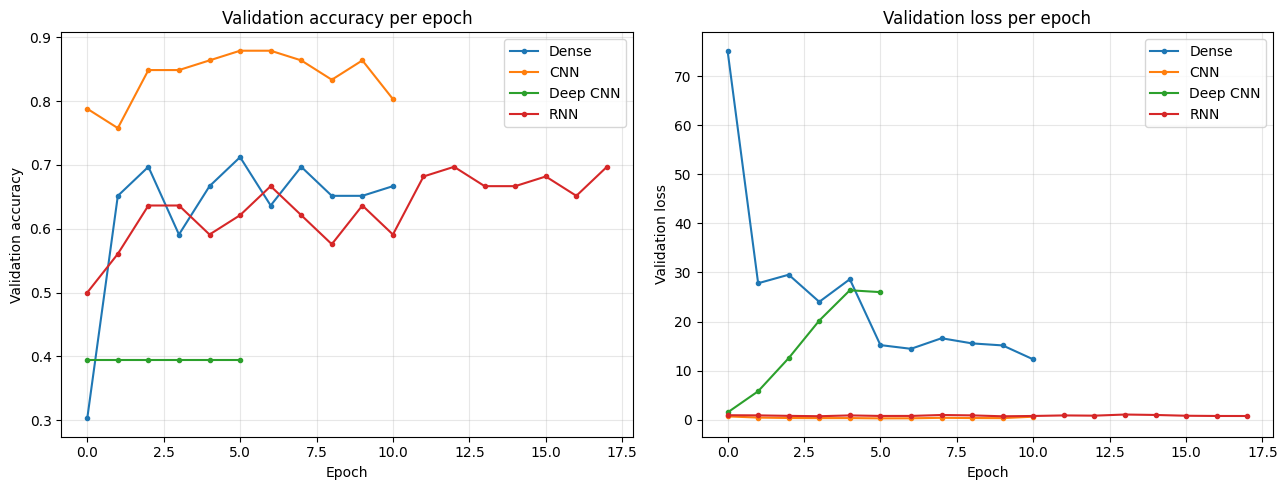

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

histories = {
    "Dense": dense_history,
    "CNN": cnn_history,
    "Deep CNN": deep_cnn_history,
    "RNN": rnn_history,
}

for name, h in histories.items():
    axes[0].plot(h.history["val_accuracy"], label=name, marker="o", markersize=3)
axes[0].set_title("Validation accuracy per epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

for name, h in histories.items():
    axes[1].plot(h.history["val_loss"], label=name, marker="o", markersize=3)
axes[1].set_title("Validation loss per epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Picking the best model

Review the table and plots above, then decide based on:
- **Test accuracy** and **Macro F1** (F1 matters more than accuracy if classes are imbalanced or if some misclassifications — e.g. missing a real Covid case — are costlier than others)
- **Params** — a much larger model that only marginally outperforms a smaller one may not be worth the added complexity/training cost
- **Validation curves** — a model whose validation accuracy plateaus early or is unstable (jagged) may be less reliable than one with a smooth, steady climb

Once you've picked a winner, save it for later use:

```python
best_model = cnn_model   # <- replace with whichever model actually wins
best_model.save("best_covid_model.keras")
```